<a href="https://colab.research.google.com/github/hariharan-075/ML_hackathon/blob/main/sales_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Step 1: Environment Setup and Data Loading
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from google.colab import files

warnings.filterwarnings('ignore')

# Note: This assumes train.csv, test.csv, and store.csv are uploaded
train = pd.read_csv('train.csv', parse_dates=['Date'])
test = pd.read_csv('test.csv', parse_dates=['Date'])
store = pd.read_csv('store.csv')

# Merge store metadata
train = train.merge(store, on='Store', how='left')
test = test.merge(store, on='Store', how='left')

print(f"Data Loaded. Train: {train.shape}, Test: {test.shape}")

Data Loaded. Train: (1017209, 18), Test: (41088, 17)


Load and Merge Datasets

In [ ]:
# Step 2: Load and Merge Datasets
import pandas as pd, numpy as np, warnings
warnings.filterwarnings('ignore')

train = pd.read_csv('train.csv', parse_dates=['Date'])
store = pd.read_csv('store.csv')
test  = pd.read_csv('test.csv',  parse_dates=['Date'])

train = train.merge(store, on='Store').sort_values(['Store','Date']).reset_index(drop=True)
test  = test.merge(store,  on='Store').sort_values(['Store','Date']).reset_index(drop=True)
print("Loaded — train:", train.shape, "| test:", test.shape)

Loaded — train: (1017209, 18) | test: (41088, 17)


Preprocessing and Temporal Features

In [ ]:
# Step 2: Preprocessing & Feature Engineering
def feature_pipeline(df, is_train=True):
    # 1. Date Features
    df['Year'] = df['Date'].dt.year
    df['Month'] = df['Date'].dt.month
    df['Day'] = df['Date'].dt.day
    df['DayOfWeek'] = df['Date'].dt.dayofweek
    df['WeekOfYear'] = df['Date'].dt.isocalendar().week.astype(int)

    # 2. Impute missing sales (Time-aware interpolation)
    if is_train:
        df['Sales'] = df['Sales'].replace(0, np.nan)
        df['Sales'] = df.groupby('Store')['Sales'].transform(lambda x: x.interpolate(method='linear'))
        df['Sales'] = df['Sales'].fillna(method='bfill')

    # 3. Competition Features
    df['CompetitionOpenSinceYear'] = df['CompetitionOpenSinceYear'].fillna(1900)
    df['CompetitionOpenSinceMonth'] = df['CompetitionOpenSinceMonth'].fillna(1)
    df['CompetitionOpen'] = 12 * (df['Year'] - df['CompetitionOpenSinceYear']) + (df['Month'] - df['CompetitionOpenSinceMonth'])
    df['CompetitionOpen'] = df['CompetitionOpen'].clip(lower=0)

    # 4. Lag and EWMA Features (Modified to use available Sales only)
    df = df.sort_values(['Store', 'Date'])
    lags = [7, 14, 28, 364]
    for lag in lags:
        source_col = 'Sales' if 'Sales' in df.columns else None
        if source_col:
            df[f'lag_{lag}'] = df.groupby('Store')[source_col].shift(lag)
            df[f'ewma_{lag}'] = df.groupby('Store')[source_col].transform(lambda x: x.ewm(span=lag).mean())

    # 5. Encoding
    df['StateHoliday'] = df['StateHoliday'].astype(str)
    df['StoreType'] = df['StoreType'].astype(str)
    df['Assortment'] = df['Assortment'].astype(str)

    return df

# Apply basic processing
train = feature_pipeline(train, is_train=True)
test = feature_pipeline(test, is_train=False)

 LAG + EWMA FEATURES

Categorical Encoding and Train-Test Alignment

In [ ]:
# Step 3: Train-Test Alignment & Encoding
# Drop columns that won't be used or are too sparse
cols_to_drop = ['PromoInterval', 'Date']
train_clean = train.drop(columns=cols_to_drop, errors='ignore')
test_clean = test.drop(columns=cols_to_drop, errors='ignore')

# One-Hot Encoding
train_encoded = pd.get_dummies(train_clean)
test_encoded = pd.get_dummies(test_clean)

# Align columns
features = [c for c in train_encoded.columns if c not in ['Sales']]
test_encoded = test_encoded.reindex(columns=features, fill_value=0)

print(f"Final feature count: {len(features)}")

Final feature count: 36


In [ ]:
train = train.dropna()

TASK - 2

In [ ]:
train = train.drop(columns=['PromoInterval'], errors='ignore')
test  = test.drop(columns=['PromoInterval'], errors='ignore')

Initialising LightGBM Regressor


In [ ]:
import lightgbm as lgb
model = lgb.LGBMRegressor(n_estimators=1000, learning_rate=0.05, num_leaves=31)

feature selection


In [ ]:
X = train_encoded[features]
y = train_encoded['Sales']

# Train the model
print(f"Training model on {len(features)} features...")
model.fit(X, y)
print("Model trained successfully.")

Training model on 36 features...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.152586 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3271
[LightGBM] [Info] Number of data points in the train set: 1017209, number of used features: 36
[LightGBM] [Info] Start training from score 6982.456448
Model trained successfully.


Displaying a sample of predictions


Visualize Feature Importance


Core ML - Validation (RMSPE)

In [ ]:
import lightgbm as lgb

def rmspe(y_true, y_pred):
    mask = y_true != 0
    return np.sqrt(np.mean(np.square((y_true[mask] - y_pred[mask]) / y_true[mask]))) * 100

# Time-based split for validation (last 42 days)
val_cutoff = train['Date'].max() - pd.Timedelta(days=42)

# Re-define sets to ensure train_encoded/features are available in this scope
train_encoded['Date'] = train['Date'].values

X_train = train_encoded[train_encoded['Date'] <= val_cutoff][features]
y_train = train_encoded[train_encoded['Date'] <= val_cutoff]['Sales']
X_val = train_encoded[train_encoded['Date'] > val_cutoff][features]
y_val = train_encoded[train_encoded['Date'] > val_cutoff]['Sales']

params = {
    'n_estimators': 500,
    'learning_rate': 0.1,
    'num_leaves': 63,
    'objective': 'regression',
    'metric': 'rmse',
    'n_jobs': -1
}

model = lgb.LGBMRegressor(**params)
model.fit(X_train, y_train, eval_set=[(X_val, y_val)], callbacks=[lgb.early_stopping(stopping_rounds=50)])

val_preds = model.predict(X_val)
print(f"\nValidation RMSPE: {rmspe(y_val, val_preds):.4f}%")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.166391 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2506
[LightGBM] [Info] Number of data points in the train set: 970379, number of used features: 33
[LightGBM] [Info] Start training from score 6983.481344
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[500]	valid_0's rmse: 500.779

Validation RMSPE: 7.1924%


Final Forecast Generation


Forecast for the next 42 days (Sample):


,Store,Date,Sales_Pred
0,1,2015-08-01,2283.136349
1,1,2015-08-02,2086.088366
2,1,2015-08-03,3086.803636
3,1,2015-08-04,2660.984776
4,1,2015-08-05,2593.968931
5,1,2015-08-06,2542.060704
6,1,2015-08-07,2534.933400
7,1,2015-08-08,2276.481188
8,1,2015-08-09,2135.383746
9,1,2015-08-10,2413.098840


<Figure size 1000x800 with 0 Axes>

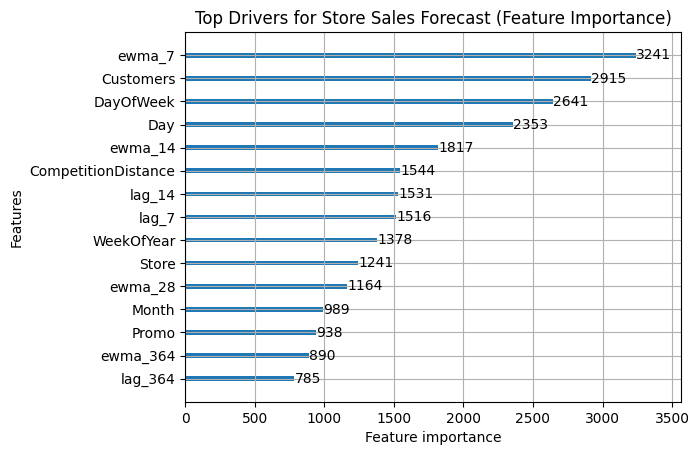

In [ ]:
import matplotlib.pyplot as plt
import lightgbm as lgb

# Ensure we use the aligned test_encoded created in Step 3
# and the specific features list used to train the model
if 'test_encoded' in globals():
    # Align and fill missing values (common in lag features for future dates)
    X_test = test_encoded[features].fillna(0)
    test['Sales_Pred'] = model.predict(X_test)

    print("Forecast for the next 42 days (Sample):")
    display(test[['Store', 'Date', 'Sales_Pred']].head(15))
    # the extra feature of our hackathon
    # Visualizing Feature Importance
    plt.figure(figsize=(10, 8))
    lgb.plot_importance(model, max_num_features=15, importance_type='split')
    plt.title('Top Drivers for Store Sales Forecast (Feature Importance)')
    plt.show()
else:
    print("Error: 'test_encoded' not found. Please ensure the 'Train-Test Alignment & Encoding' cell has been executed.")